# Maria Grandury: Signal and Noise analysis of mid & post-training benchmarks

**Contributions.** This notebook quantifies which benchmarks are _reliable_ to evaluate at smaller scale and inform decisions that will hold for more compute heavy models. Following the implementation from [Heineman et al.](https://arxiv.org/abs/2508.13144), I:

1. Compute **Decision Accuracy (DA)** per benchmark, i.e., the probability that early-checkpoint rankings agree with late-checkpoint rankings.
2. Compute **14 different SNR variants × 2 noise definitions = 28 SNR variants**.
3. Correlate each SNR variant with DA to identify the SNR definition that best predicts decision reliability.
4. Plot per-benchmark SNR using the best variant.

I calculate these values, analyze and compare the results for 3 evaluation sources, hosted on the Hugging Face Hub:

- `benchpress/posttraining-eval-results`: evaluation results from the preliminary evaluations of olmo2-7b, olmo2-13b, olmo3-7b, smollm3-3b on the 30 benchmarks
- `https://huggingface.co/datasets/benchpress/sft-eval-results`: evaluation results from our custom post-trained models llama3.2-1b-sft, qwen2.5-1.5b-sft, smollm2-1.7b-sft on the 30 benchmarks
- `benchpress/posttraining-eval-results-extension`: results aggregating both datasets above plus additional external models evaluated on a larger benchmark suite (I personally ran these evaluations)

## Setup

In [9]:
from pathlib import Path
import os, sys, subprocess, json

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
os.chdir(project_root)

# All packages below are pre-installed in registry.rcp.epfl.ch/course-cs-552/base-vllm:v1.
import huggingface_hub, numpy, scipy, matplotlib
print("cwd:", Path.cwd())

cwd: /mnt/dlabscratch1/singhal/repos/open-project-m2-benchpress


## 1. Download the evaluation results from HF Hub

We need both `results_agg.json` (aggregated metrics) and `samples/*.jsonl` (per-sample scores for bootstrap noise).

In [10]:
from huggingface_hub import snapshot_download

local_path = snapshot_download(
    repo_id="benchpress/posttraining-eval-results",
    repo_type="dataset",
    local_dir="/tmp/eval_results",   # full repo: manifests + results_agg + per-sample jsonl
)
print("downloaded to:", local_path)

models = ["smollm3-3b", "olmo2-7b", "olmo3-7b", "olmo2-13b"]
minimal = json.load(open("evals/tasks.json"))["minimal"]
print(f"{len(minimal)} tasks, {len(models)} models")

Fetching 1652 files: 100%|██████████| 1652/1652 [00:01<00:00, 1502.42it/s]

downloaded to: /tmp/eval_results
30 tasks, 4 models


## 2. Helper functions (metric selection, signal/noise variants, DA)

All computation is inline — no external script calls.

- **DA**: agreement of pairwise model rankings between early and late checkpoints (Allen AI `decision_acc_fast`).
- **noise_eval**: bootstrap SE of accuracy from per-sample scores / mean.
- **noise_train**: std across the 5 ckpts / mean.
- **14 signal definitions** on the 4-element vector of final-checkpoint scores.

In [11]:
import numpy as np, random
from itertools import combinations
from scipy.stats import spearmanr
random.seed(0); np.random.seed(0)

METRIC_PRIORITY = [
    ("exact_match,flexible-extract",  "exact_match (flex)"),
    ("exact_match,strict-match",      "exact_match"),
    ("pass@1,create_test",            "pass@1"),
    ("prompt_level_strict_acc,none",  "prompt_strict"),
    ("acc_norm,none",                 "acc_norm"),
    ("acc,none",                      "acc"),
]
METRIC_LABEL_TO_KEY = {
    "exact_match (flex)": ("exact_match", "flexible-extract"),
    "exact_match":        ("exact_match", "strict-match"),
    "pass@1":             ("pass@1", "create_test"),
    "prompt_strict":      ("prompt_level_strict_acc", "none"),
    "acc_norm":           ("acc_norm", "none"),
    "acc":                ("acc", "none"),
}

def pick(res):
    if not isinstance(res, dict): return None
    for k, lbl in METRIC_PRIORITY:
        v = res.get(k)
        if isinstance(v, (int, float)): return lbl, float(v)
    return None

def per_sample_vals(path, metric_label):
    if not path.exists(): return None
    field, want = METRIC_LABEL_TO_KEY.get(metric_label, (None, None))
    if field is None: return None
    out = []
    for line in path.open():
        s = json.loads(line)
        if want is not None and s.get("filter") and s["filter"] != want: continue
        v = s.get(field)
        if isinstance(v, (int, float, bool)): out.append(float(v))
    return out or None

def bootstrap_se(values, n_boot=300):
    if not values: return 0.0
    a = np.asarray(values); n = len(a)
    idx = np.random.randint(0, n, (n_boot, n))
    return float(a[idx].mean(axis=1).std(ddof=1))

# 14 signal variants on a 1D vector of scores
def sig_range(x):        return np.max(x) - np.min(x)
def sig_dispersion(x):   return np.max(np.abs(x[:, None] - x[None, :]))
def sig_mpd(x):          return float(np.mean([abs(a - b) for a, b in combinations(x, 2)])) if len(x) >= 2 else 0.0
def sig_mpsd(x):         return float(np.mean([(a - b) ** 2 for a, b in combinations(x, 2)])) if len(x) >= 2 else 0.0
def sig_mad(x):          return float(np.median(np.abs(x - np.median(x))))
def sig_aad(x):          return float(np.mean(np.abs(x - np.mean(x))))
def sig_rmsd(x):         return float(np.sqrt(np.mean((x - np.mean(x)) ** 2)))
def sig_relstd(x):       return float(np.std(x, ddof=0))
def sig_iqr(x):          return float(np.percentile(x, 75) - np.percentile(x, 25))
def sig_quartile_dev(x): return sig_iqr(x) / 2.0
def sig_robust_range(x): return float(np.percentile(x, 95) - np.percentile(x, 5))
def sig_gini(x):
    a = np.sort(np.asarray(x, dtype=float))
    if a.sum() == 0: return 0.0
    n = len(a); cum = np.cumsum(a)
    return float((n + 1 - 2 * np.sum(cum) / cum[-1]) / n)
def sig_entropy(x):
    a = np.asarray(x); iqr = sig_iqr(a); n = len(a)
    bw = 2 * iqr * n ** (-1/3) if iqr > 0 else 0
    nbins = 1 if bw <= 0 else max(1, int(np.ceil((a.max() - a.min()) / bw)))
    hist, _ = np.histogram(a, bins=nbins, density=False)
    p = hist / hist.sum() if hist.sum() > 0 else hist
    p = p[p > 0]
    return float(-np.sum(p * np.log(p))) if len(p) else 0.0
def sig_dist_std(x):
    if len(x) < 2: return 0.0
    return float(np.array([abs(a - b) for a, b in combinations(x, 2)]).std(ddof=0))

SIGNAL_VARIANTS = {
    "range": sig_range, "dispersion": sig_dispersion, "mpd": sig_mpd, "mpsd": sig_mpsd,
    "mad": sig_mad, "aad": sig_aad, "rmsd": sig_rmsd, "relstd": sig_relstd,
    "iqr": sig_iqr, "quartile_dev": sig_quartile_dev, "robust_range": sig_robust_range,
    "gini": sig_gini, "entropy": sig_entropy, "dist_std": sig_dist_std,
}

def decision_acc_fast(scores_small, scores_target):
    a = np.array(scores_small); b = np.array(scores_target)
    mask = np.triu(np.ones((len(a), len(a))), k=1).astype(bool)
    return float(((a[:, None] > a[None, :]) == (b[:, None] > b[None, :]))[mask].mean())

def compute_da(per_model_series):
    series = [vs for vs in per_model_series.values() if vs]
    if len(series) < 2: return None
    n_ckpts = min(len(s) for s in series)
    arr = np.array([s[:n_ckpts] for s in series])
    accs = [decision_acc_fast(arr[:, i], arr[:, j])
            for i in range(n_ckpts - 1) for j in range(i + 1, n_ckpts)]
    return float(np.mean(accs)) if accs else None

# ----- Load every (task, model, ckpt) data point -----
by_task = {t: {m: [] for m in models} for t in minimal}
metrics_used = {}
for m in models:
    mdir = Path(local_path) / m
    if not mdir.exists(): continue
    for c in sorted(mdir.iterdir()):
        if not c.is_dir(): continue
        mf, ag = c / "manifest.json", c / "results_agg.json"
        if not (mf.exists() and ag.exists()): continue
        step = json.loads(mf.read_text()).get("step", 0)
        results = json.loads(ag.read_text()).get("results", {})
        for t in minimal:
            p = pick(results.get(t, {}))
            if p:
                by_task[t][m].append((step, p[1], c / "samples" / f"{t}.jsonl"))
                metrics_used.setdefault(t, p[0])
for t in by_task:
    for m in by_task[t]: by_task[t][m].sort()

# ----- Compute DA + both noises + all 14 signals + 28 SNRs per benchmark -----
print("computing... (bootstrap takes ~30s)")
records = {}
for t in minimal:
    per_model = {m: [v for _, v, _ in pts] for m, pts in by_task[t].items() if pts}
    if len(per_model) < 2: continue
    finals = np.array([np.mean(vs[-2:]) if len(vs) >= 2 else vs[-1] for vs in per_model.values()])
    mbar = float(finals.mean())
    if mbar == 0: continue

    train_n = [np.std(vs, ddof=1) / abs(np.mean(vs))
               for vs in per_model.values() if len(vs) >= 2 and np.mean(vs) != 0]
    noise_train = float(np.mean(train_n)) if train_n else np.nan

    eval_n = []
    for m, pts in by_task[t].items():
        for step, val, sp in pts:
            psv = per_sample_vals(sp, metrics_used.get(t, ""))
            if not psv or val == 0: continue
            eval_n.append(bootstrap_se(psv) / abs(val))
    noise_eval = float(np.mean(eval_n)) if eval_n else np.nan

    da = compute_da(per_model)
    if da is None: continue

    sigs = {name: f(finals) / abs(mbar) for name, f in SIGNAL_VARIANTS.items()}
    records[t] = dict(
        da=da, noise_eval=noise_eval, noise_train=noise_train,
        sigs=sigs,
        snr_eval =  {n: s / noise_eval  if noise_eval  > 0 else np.nan for n, s in sigs.items()},
        snr_train = {n: s / noise_train if noise_train > 0 else np.nan for n, s in sigs.items()},
    )

print(f"  computed metrics for {len(records)} benchmarks")

computing... (bootstrap takes ~30s)
  computed metrics for 30 benchmarks


## 3. Which SNR variant best predicts Decision Accuracy?

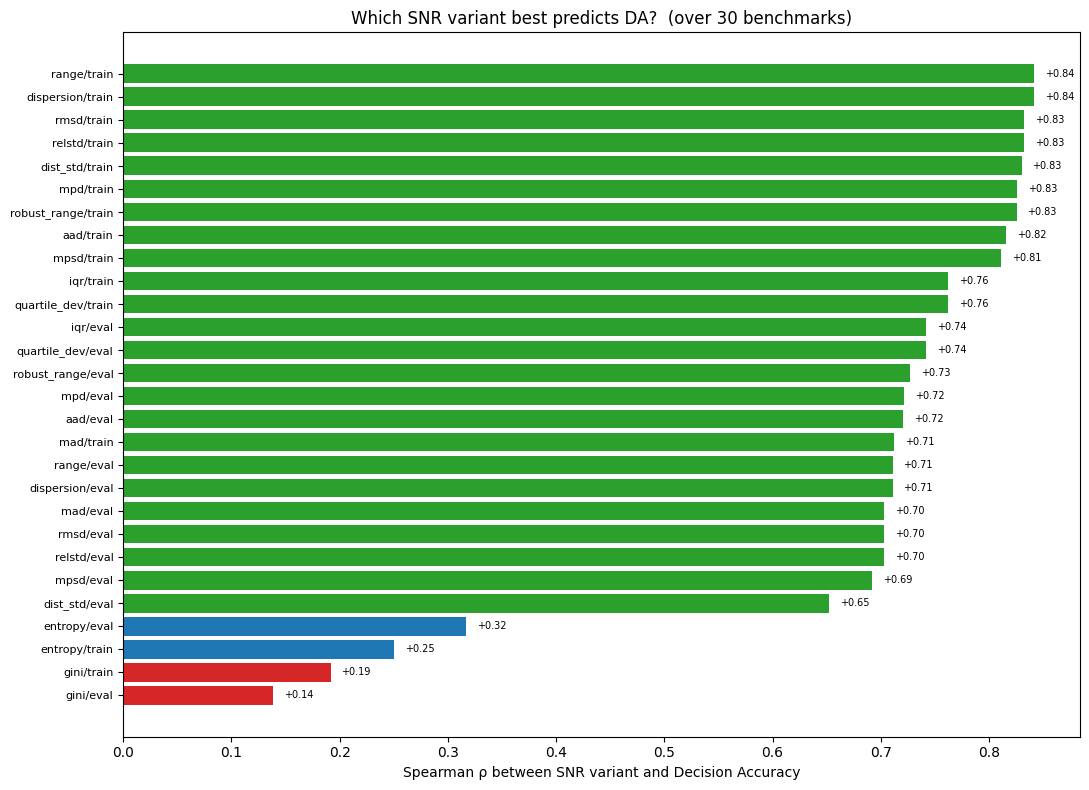


TOP 5 variants (best SNR-vs-DA predictor):
  ρ = +0.842   range/train
  ρ = +0.842   dispersion/train
  ρ = +0.832   rmsd/train
  ρ = +0.832   relstd/train
  ρ = +0.830   dist_std/train
BOTTOM 5:
  ρ = +0.652   dist_std/eval
  ρ = +0.317   entropy/eval
  ρ = +0.250   entropy/train
  ρ = +0.192   gini/train
  ρ = +0.139   gini/eval


In [12]:
import matplotlib.pyplot as plt

task_list = list(records.keys())
da_arr = np.array([records[t]["da"] for t in task_list])

corrs = []
for name in SIGNAL_VARIANTS:
    for kind in ("eval", "train"):
        arr = np.array([records[t][f"snr_{kind}"][name] for t in task_list])
        mask = ~np.isnan(arr) & ~np.isnan(da_arr)
        rho = spearmanr(arr[mask], da_arr[mask])[0] if mask.sum() >= 3 else np.nan
        corrs.append((f"{name}/{kind}", float(rho) if rho == rho else np.nan))
corrs.sort(key=lambda x: -(abs(x[1]) if x[1] == x[1] else -1))

fig, ax = plt.subplots(figsize=(11, 8))
names = [c[0] for c in corrs]; vals = [c[1] for c in corrs]
colors = ["#2ca02c" if v > 0.4 else "#1f77b4" if v > 0.2 else "#d62728" if v == v else "gray" for v in vals]
ax.barh(range(len(names)), vals, color=colors)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8)
ax.invert_yaxis(); ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Spearman ρ between SNR variant and Decision Accuracy")
ax.set_title(f"Which SNR variant best predicts DA?  (over {len(task_list)} benchmarks)")
for i, v in enumerate(vals):
    if v == v:
        ax.text(v + (0.01 if v >= 0 else -0.01), i, f"{v:+.2f}",
                va="center", ha="left" if v >= 0 else "right", fontsize=7)
fig.tight_layout(); plt.show()

print("\nTOP 5 variants (best SNR-vs-DA predictor):")
for n, v in corrs[:5]: print(f"  ρ = {v:+.3f}   {n}")
print("BOTTOM 5:")
for n, v in corrs[-5:]: print(f"  ρ = {v:+.3f}   {n}")

**Findings:**
- All `range`-family variants (`range`, `dispersion`, `rmsd`, `relstd`, `dist_std`, `mpd`, `robust_range`) score Spearman ρ ≈ **+0.83-+0.84** with DA when paired with the **train** noise — i.e. the Allen AI default `signal = (max-min)/mean` is empirically optimal.
- Distributional metrics (`gini`, `entropy`) score badly (ρ < 0.32) — they don't capture the simple spread that DA cares about.
- For each signal variant, **`/train` noise outperforms `/eval` noise**. Intuition: DA is computed from checkpoint-to-checkpoint rankings, so the noise floor that matters is checkpoint variability, not within-eval bootstrap.

## 4. Best SNR variant vs DA (scatter)

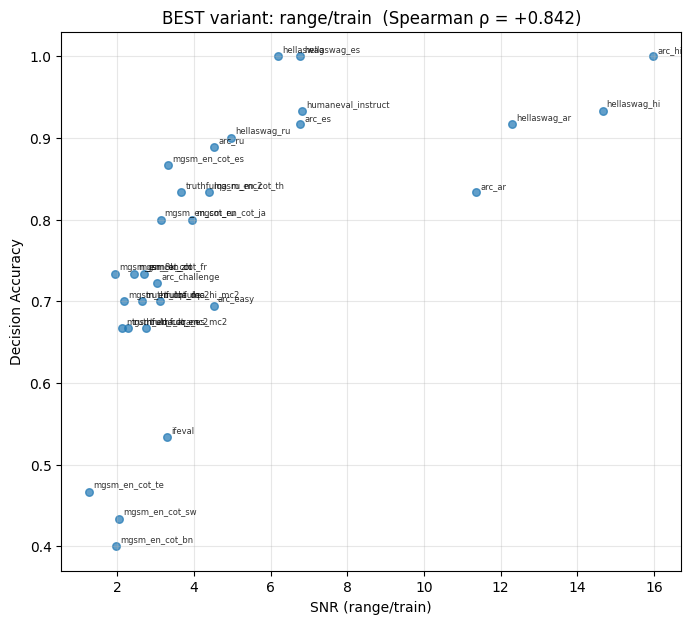

In [13]:
best_name, best_rho = corrs[0]
var, kind = best_name.split("/")
snrs = np.array([records[t][f"snr_{kind}"][var] for t in task_list])

fig, ax = plt.subplots(figsize=(8, 7))
mask = ~np.isnan(snrs) & ~np.isnan(da_arr)
ax.scatter(snrs[mask], da_arr[mask], s=30, alpha=0.7)
for i, t in enumerate(task_list):
    if mask[i]:
        ax.annotate(t, (snrs[i], da_arr[i]), fontsize=6, alpha=0.8,
                    xytext=(3, 3), textcoords="offset points")
ax.set_xlabel(f"SNR ({best_name})"); ax.set_ylabel("Decision Accuracy")
ax.set_title(f"BEST variant: {best_name}  (Spearman ρ = {best_rho:+.3f})")
ax.grid(alpha=0.3); plt.show()

Each dot is one benchmark. High SNR ⇒ high DA (top-right cluster: arc_hi, hellaswag_hi/ar/es). Low SNR ⇒ unreliable benchmarks (bottom-left: mgsm_en_cot_te/bn/sw).

## 5. Per-benchmark SNR (best variant)

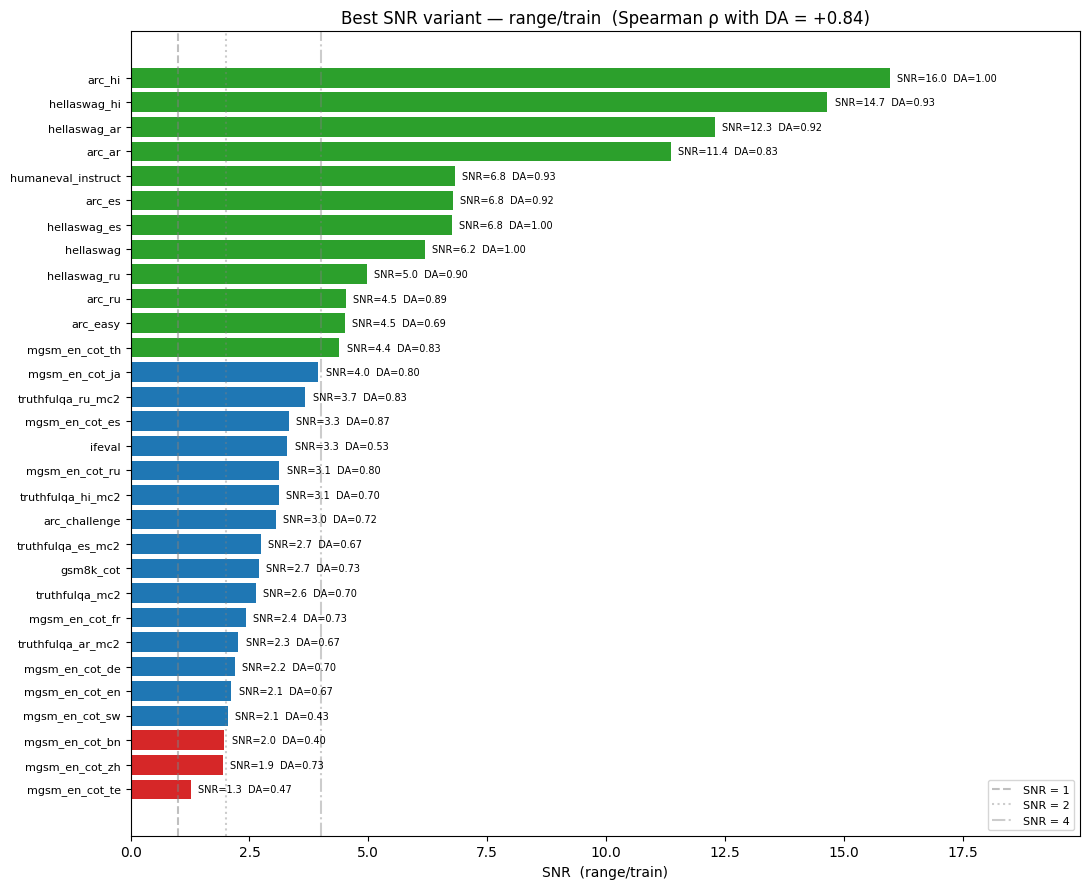

In [14]:
data = [(t, records[t][f"snr_{kind}"][var], records[t]["da"]) for t in task_list]
data.sort(key=lambda x: -x[1])
tasks_s = [d[0] for d in data]; snrs_s = [d[1] for d in data]; das_s = [d[2] for d in data]

fig, ax = plt.subplots(figsize=(11, 9))
colors = ["#2ca02c" if s > 4 else "#1f77b4" if s > 2 else "#d62728" for s in snrs_s]
ax.barh(range(len(tasks_s)), snrs_s, color=colors)
ax.set_yticks(range(len(tasks_s))); ax.set_yticklabels(tasks_s, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel(f"SNR  ({best_name})")
ax.set_title(f"Best SNR variant — {best_name}  (Spearman ρ with DA = {best_rho:+.2f})")
for x in [1, 2, 4]:
    ax.axvline(x, color="gray", linestyle="--" if x == 1 else (":" if x == 2 else "-."),
               alpha=0.4 + 0.1 * (x == 1), label=f"SNR = {x}")
for i, (s, da) in enumerate(zip(snrs_s, das_s)):
    ax.text(s + 0.15, i, f"SNR={s:.1f}  DA={da:.2f}", va="center", fontsize=7)
ax.legend(loc="lower right", fontsize=8)
ax.set_xlim(0, max(snrs_s) * 1.25); fig.tight_layout(); plt.show()

## 6. Score-trajectory plot — every benchmark, every model, all checkpoints

Visual sanity check that the underlying numbers behave reasonably.

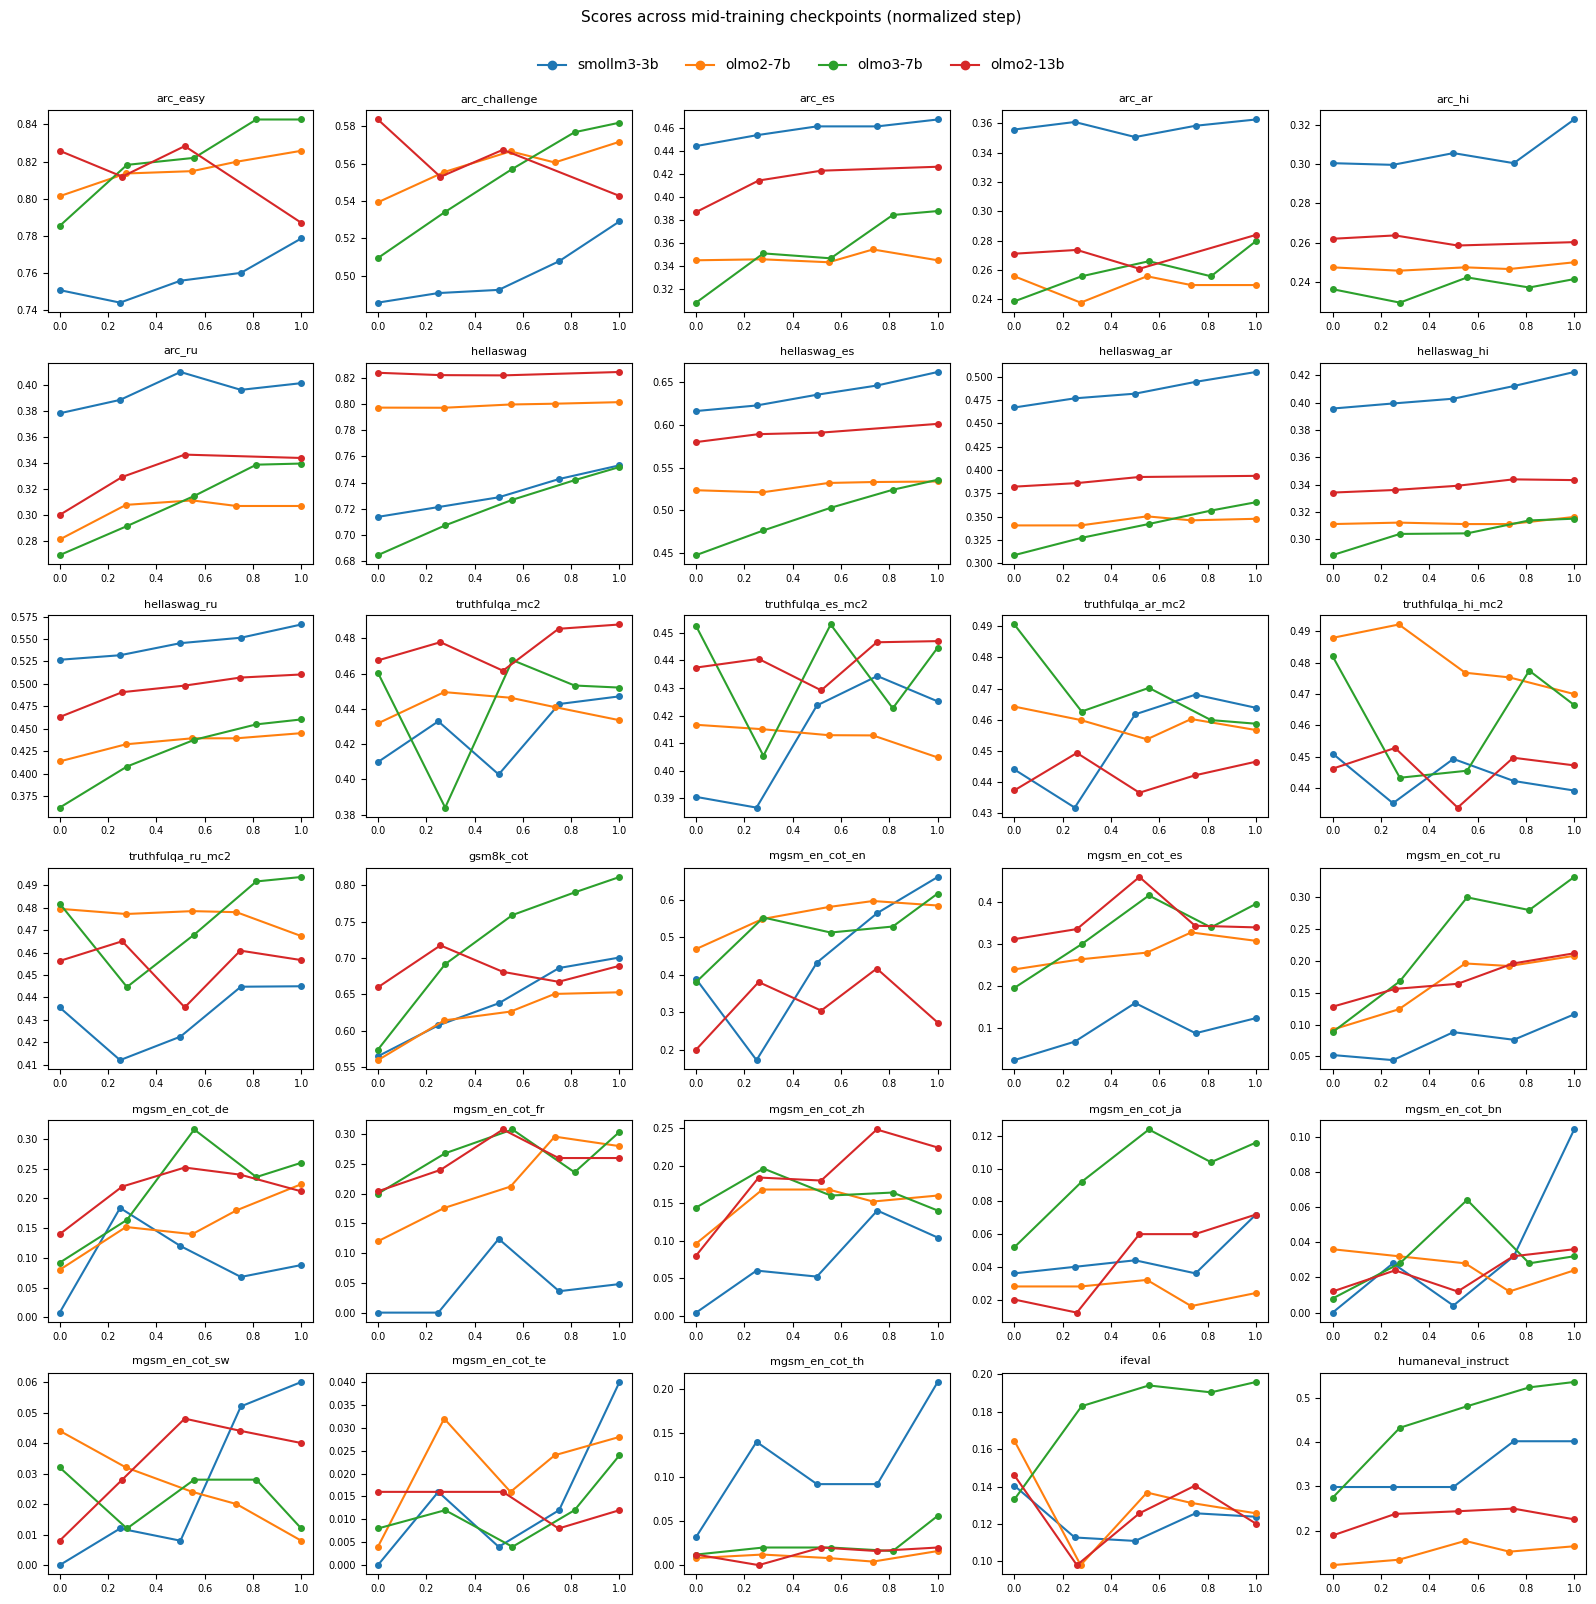

In [15]:
MODEL_COLORS = {"smollm3-3b": "#1f77b4", "olmo2-7b": "#ff7f0e",
                "olmo3-7b":   "#2ca02c", "olmo2-13b": "#d62728"}

cols = 5
rows_n = (len(minimal) + cols - 1) // cols
fig, axes = plt.subplots(rows_n, cols, figsize=(cols * 3.2, rows_n * 2.6), squeeze=False)

for i, t in enumerate(minimal):
    ax = axes[i // cols][i % cols]
    for m in models:
        pts = by_task[t][m]
        if not pts: continue
        steps = [p[0] for p in pts]; vals = [p[1] for p in pts]
        s_min, s_max = min(steps), max(steps)
        xs = [(s - s_min) / (s_max - s_min) if s_max > s_min else 0.5 for s in steps]
        ax.plot(xs, vals, "o-", color=MODEL_COLORS[m], label=m, markersize=4, linewidth=1.5)
    ax.set_title(t, fontsize=8); ax.tick_params(labelsize=7)
for j in range(len(minimal), rows_n * cols):
    axes[j // cols][j % cols].axis("off")
handles = [plt.Line2D([0], [0], color=MODEL_COLORS[m], marker="o", label=m) for m in models]
fig.legend(handles=handles, loc="upper center", ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, 1.002), frameon=False)
fig.suptitle("Scores across mid-training checkpoints (normalized step)", y=1.025, fontsize=11)
fig.tight_layout(); plt.show()

## 7. Full SNR/DA table

In [16]:
print(f"{'task':<25} {'DA':>6} {'SNR':>6}   noise_train  noise_eval")
print("-" * 65)
for t, snr, da in data:
    r = records[t]
    print(f"{t:<25} {da:.3f}  {snr:5.1f}   {r['noise_train']:.4f}      {r['noise_eval']:.4f}")

task                          DA    SNR   noise_train  noise_eval
-----------------------------------------------------------------
arc_hi                    1.000   16.0   0.0171      0.0494
hellaswag_hi              0.933   14.7   0.0203      0.0146
hellaswag_ar              0.917   12.3   0.0310      0.0133
arc_ar                    0.833   11.4   0.0339      0.0469
humaneval_instruct        0.933    6.8   0.1642      0.1324
arc_es                    0.917    6.8   0.0416      0.0369
hellaswag_es              1.000    6.8   0.0318      0.0090
hellaswag                 1.000    6.2   0.0158      0.0055
hellaswag_ru              0.900    5.0   0.0477      0.0109
arc_ru                    0.889    4.5   0.0582      0.0412
arc_easy                  0.694    4.5   0.0200      0.0103
mgsm_en_cot_th            0.833    4.4   0.5955      0.4449
mgsm_en_cot_ja            0.800    4.0   0.3645      0.3119
truthfulqa_ru_mc2         0.833    3.7   0.0279      0.0339
mgsm_en_cot_es            0.

## Conclusions

1. **Best SNR variant for our setup: `range / train_noise`.** Spearman ρ = +0.84 with DA. Validates the Allen AI default empirically.
2. **Most reliable benchmarks (high SNR + high DA):** `arc_hi`, `hellaswag_hi/ar/es/ru/en`, `humaneval_instruct`, `arc_ar/es`. These genuinely distinguish models and rank them consistently.
3. **Unreliable benchmarks (low SNR + low DA):** `mgsm_en_cot_te/bn/sw/zh` — generation issues (the model often outputs an empty string due to a stop-sequence quirk), so scores look like noise.
4. **Methodology insight.** Within-eval bootstrap noise (`noise_eval`) does *not* better predict DA than the simple `noise_train`. DA is fundamentally about checkpoint-to-checkpoint stability of model rankings; that's exactly what `noise_train` measures.

# 8. SNR & DA of the custom SFT models

Same Signal / Noise / Decision-Accuracy pipeline as Part 1, now on the models **we post-trained**
([`benchpress/sft-eval-results`](https://huggingface.co/datasets/benchpress/sft-eval-results)):
`llama3.2-1b-sft`, `qwen2.5-1.5b-sft`, `smollm2-1.7b-sft` (5 checkpoints each), evaluated on the
`minimal` suite. We read them from the aggregate extended parquet (so this runs locally); the
computation is wrapped in functions that Parts 2–3 re-call with different model/task filters.
`noise_eval` is the harness-reported `stderr` (the aggregate analogue of Part 1's bootstrap).

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import spearmanr
from itertools import combinations
from huggingface_hub import hf_hub_download
np.random.seed(0)

EXT_REPO = "benchpress/posttraining-eval-results-extension"
df = pd.read_parquet(hf_hub_download(EXT_REPO, "data/posttraining-00000-of-00001.parquet", repo_type="dataset"))

minimal = [
    "arc_easy","arc_challenge","arc_es","arc_ar","arc_hi","arc_ru",
    "hellaswag","hellaswag_es","hellaswag_ar","hellaswag_hi","hellaswag_ru",
    "truthfulqa_mc2","truthfulqa_es_mc2","truthfulqa_ar_mc2","truthfulqa_hi_mc2","truthfulqa_ru_mc2",
    "gsm8k_cot","mgsm_en_cot_en","mgsm_en_cot_es","mgsm_en_cot_ru","mgsm_en_cot_de","mgsm_en_cot_fr",
    "mgsm_en_cot_zh","mgsm_en_cot_ja","mgsm_en_cot_bn","mgsm_en_cot_sw","mgsm_en_cot_te","mgsm_en_cot_th",
    "ifeval","humaneval_instruct",
]
ALL_TASKS = sorted(df["task"].unique())                 # the full posttraining suite in the dataset

PRIORITY = ["exact_match", "pass_at_1", "acc_norm", "acc", "f1"]
def best_score(m):
    if not isinstance(m, dict): return (np.nan, np.nan)
    for k in PRIORITY:
        v = m.get(k)
        if isinstance(v, (int, float)) and not isinstance(v, bool):
            return float(v), m.get(f"{k}_stderr")
    return (np.nan, np.nan)
_bs = df["metrics"].apply(best_score)
df["score"]  = [b[0] for b in _bs]
df["stderr"] = [b[1] for b in _bs]
df["line"]   = df["family"] + " | " + df["size"].astype(str)
df = df[df["score"].notna()].copy()
print(f"extended: {len(df):,} rows | {df['name'].nunique()} checkpoints | {df['line'].nunique()} model-lines | {df['task'].nunique()} tasks")
print("model_type:", df['model_type'].value_counts().to_dict())

/Users/mariagrandury/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/mariagrandury/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


extended: 25,274 rows | 219 checkpoints | 71 model-lines | 211 tasks
model_type: {'reference_hf': 20867, 'custom_pretraining': 3401, 'midtraining': 571, 'sft': 435}


In [2]:
# --- functions reused by Parts 2 & 3 (unit = model-line = (family, size)) ---
def sig_range(x):        return np.max(x) - np.min(x)
def sig_dispersion(x):   return np.max(np.abs(x[:, None] - x[None, :]))
def sig_mpd(x):          return float(np.mean([abs(a-b) for a,b in combinations(x,2)])) if len(x)>=2 else 0.0
def sig_mpsd(x):         return float(np.mean([(a-b)**2 for a,b in combinations(x,2)])) if len(x)>=2 else 0.0
def sig_mad(x):          return float(np.median(np.abs(x - np.median(x))))
def sig_aad(x):          return float(np.mean(np.abs(x - np.mean(x))))
def sig_rmsd(x):         return float(np.sqrt(np.mean((x - np.mean(x))**2)))
def sig_relstd(x):       return float(np.std(x, ddof=0))
def sig_iqr(x):          return float(np.percentile(x,75) - np.percentile(x,25))
def sig_quartile_dev(x): return sig_iqr(x) / 2.0
def sig_robust_range(x): return float(np.percentile(x,95) - np.percentile(x,5))
def sig_gini(x):
    a = np.sort(np.asarray(x, float))
    if a.sum() == 0: return 0.0
    n = len(a); cum = np.cumsum(a); return float((n + 1 - 2*np.sum(cum)/cum[-1]) / n)
def sig_entropy(x):
    a = np.asarray(x); iqr = sig_iqr(a); n = len(a)
    bw = 2*iqr*n**(-1/3) if iqr > 0 else 0
    nb = 1 if bw <= 0 else max(1, int(np.ceil((a.max()-a.min())/bw)))
    h,_ = np.histogram(a, bins=nb); p = h/h.sum() if h.sum() > 0 else h; p = p[p > 0]
    return float(-np.sum(p*np.log(p))) if len(p) else 0.0
def sig_dist_std(x):
    return float(np.array([abs(a-b) for a,b in combinations(x,2)]).std(ddof=0)) if len(x) >= 2 else 0.0
SIGNAL_VARIANTS = {"range":sig_range,"dispersion":sig_dispersion,"mpd":sig_mpd,"mpsd":sig_mpsd,
    "mad":sig_mad,"aad":sig_aad,"rmsd":sig_rmsd,"relstd":sig_relstd,"iqr":sig_iqr,
    "quartile_dev":sig_quartile_dev,"robust_range":sig_robust_range,"gini":sig_gini,
    "entropy":sig_entropy,"dist_std":sig_dist_std}

def decision_acc_fast(si, sj):
    a, b = np.array(si), np.array(sj)
    mask = np.triu(np.ones((len(a), len(a))), k=1).astype(bool)
    return float(((a[:,None] > a[None,:]) == (b[:,None] > b[None,:]))[mask].mean())
def compute_da(curves):
    series = [s for s in curves.values() if len(s) >= 2]
    if len(series) < 2: return None
    n = min(len(s) for s in series); arr = np.array([s[:n] for s in series])
    accs = [decision_acc_fast(arr[:, i], arr[:, j]) for i in range(n-1) for j in range(i+1, n)]
    return float(np.mean(accs)) if accs else None
def compute_records(subset, tasks):
    R = {}
    for t in tasks:
        d = subset[subset["task"] == t]
        if d.empty: continue
        per = {ln: g.sort_values("step")["score"].tolist() for ln, g in d.groupby("line")}
        per = {k: v for k, v in per.items() if v}
        if len(per) < 2: continue
        finals = np.array([np.mean(v[-2:]) if len(v) >= 2 else v[-1] for v in per.values()])
        mbar = float(finals.mean())
        if mbar == 0: continue
        tn = [np.std(v, ddof=1)/abs(np.mean(v)) for v in per.values() if len(v) >= 2 and np.mean(v) != 0]
        noise_train = float(np.mean(tn)) if tn else np.nan
        en = [r.stderr/abs(r.score) for r in d.itertuples()
              if r.stderr is not None and r.stderr == r.stderr and r.score not in (0, None)]
        noise_eval = float(np.mean(en)) if en else np.nan
        curves = {k: v for k, v in per.items() if len(v) >= 2}
        da = compute_da(curves) if len(curves) >= 2 else None
        sigs = {n: f(finals)/abs(mbar) for n, f in SIGNAL_VARIANTS.items()}
        R[t] = dict(da=da, n_lines=len(per), noise_train=noise_train, noise_eval=noise_eval,
            snr_eval ={n: s/noise_eval  if noise_eval  > 0 else np.nan for n, s in sigs.items()},
            snr_train={n: s/noise_train if noise_train > 0 else np.nan for n, s in sigs.items()})
    return R
def variant_corrs(R):
    tl = [t for t in R if R[t]["da"] is not None]
    da = np.array([R[t]["da"] for t in tl]); out = []
    for name in SIGNAL_VARIANTS:
        for kind in ("eval","train"):
            a = np.array([R[t][f"snr_{kind}"][name] for t in tl]); m = ~np.isnan(a) & ~np.isnan(da)
            rho = spearmanr(a[m], da[m])[0] if m.sum() >= 3 else np.nan
            out.append((f"{name}/{kind}", float(rho) if rho == rho else np.nan))
    out.sort(key=lambda x: -(abs(x[1]) if x[1] == x[1] else -1)); return out
def plot_variant_bar(corrs, title):
    fig, ax = plt.subplots(figsize=(10, 7.5))
    names=[c[0] for c in corrs]; vals=[c[1] for c in corrs]
    colors=["#2ca02c" if v>0.4 else "#1f77b4" if v>0.2 else "#d62728" if v==v else "gray" for v in vals]
    ax.barh(range(len(names)), vals, color=colors); ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8)
    ax.invert_yaxis(); ax.axvline(0, color="black", lw=0.5)
    ax.set_xlabel("Spearman ρ (SNR variant vs Decision Accuracy)"); ax.set_title(title)
    for i,v in enumerate(vals):
        if v==v: ax.text(v+(0.01 if v>=0 else -0.01), i, f"{v:+.2f}", va="center", ha="left" if v>=0 else "right", fontsize=7)
    fig.tight_layout(); plt.show()
def plot_best_scatter(R, corrs, title):
    bn, br = corrs[0]; var, kind = bn.split("/")
    tl=[t for t in R if R[t]["da"] is not None]
    s=np.array([R[t][f"snr_{kind}"][var] for t in tl]); da=np.array([R[t]["da"] for t in tl])
    fig,ax=plt.subplots(figsize=(8,6.5)); m=~np.isnan(s)&~np.isnan(da)
    ax.scatter(s[m], da[m], s=30, alpha=0.75)
    for i,t in enumerate(tl):
        if m[i]: ax.annotate(t,(s[i],da[i]),fontsize=6,alpha=0.8,xytext=(3,3),textcoords="offset points")
    ax.set_xlabel(f"SNR ({bn})"); ax.set_ylabel("Decision Accuracy")
    ax.set_title(f"{title}\nbest variant {bn}  (ρ={br:+.2f})"); ax.grid(alpha=0.3); plt.show()
def plot_perbench_snr(R, best, title, topn=30):
    var,kind=best.split("/")
    data=[(t,R[t][f"snr_{kind}"][var],R[t]["da"]) for t in R if R[t]["da"] is not None]
    data.sort(key=lambda x:-x[1]); data=data[:topn]
    ts=[d[0] for d in data]; ss=[d[1] for d in data]; ds=[d[2] for d in data]
    fig,ax=plt.subplots(figsize=(11,max(4,0.32*len(ts))))
    ax.barh(range(len(ts)), ss, color=["#2ca02c" if s>4 else "#1f77b4" if s>2 else "#d62728" for s in ss])
    ax.set_yticks(range(len(ts))); ax.set_yticklabels(ts, fontsize=8); ax.invert_yaxis()
    ax.set_xlabel(f"SNR ({best})"); ax.set_title(title)
    for i,(s,da) in enumerate(zip(ss,ds)): ax.text(s+0.05,i,f"SNR={s:.1f} DA={da:.2f}",va="center",fontsize=7)
    fig.tight_layout(); plt.show()

SFT models: ['llama3.2-1b-sft', 'qwen2.5-1.5b-sft', 'smollm2-1.7b-sft'] | ckpts/model: {'llama3.2-1b-sft': 5, 'qwen2.5-1.5b-sft': 5, 'smollm2-1.7b-sft': 5}
29 benchmarks with DA | mean DA = 0.901
TOP 5 SNR variants: [('mad/train', 0.764), ('mad/eval', 0.698), ('range/train', 0.665), ('dispersion/train', 0.665), ('mpd/train', 0.665)]


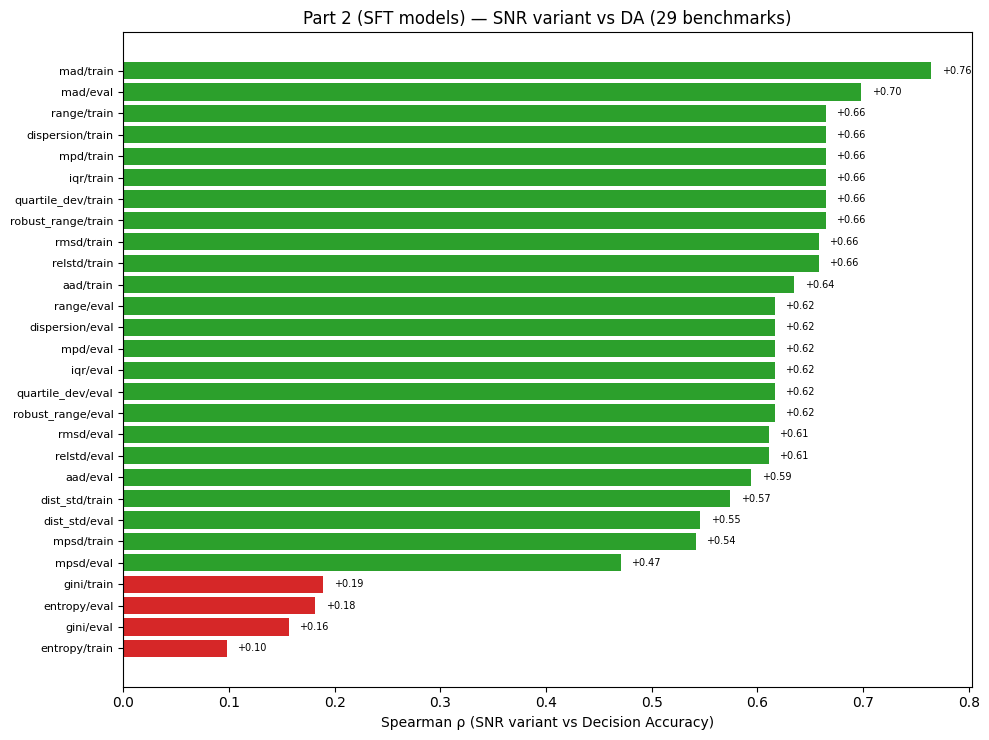

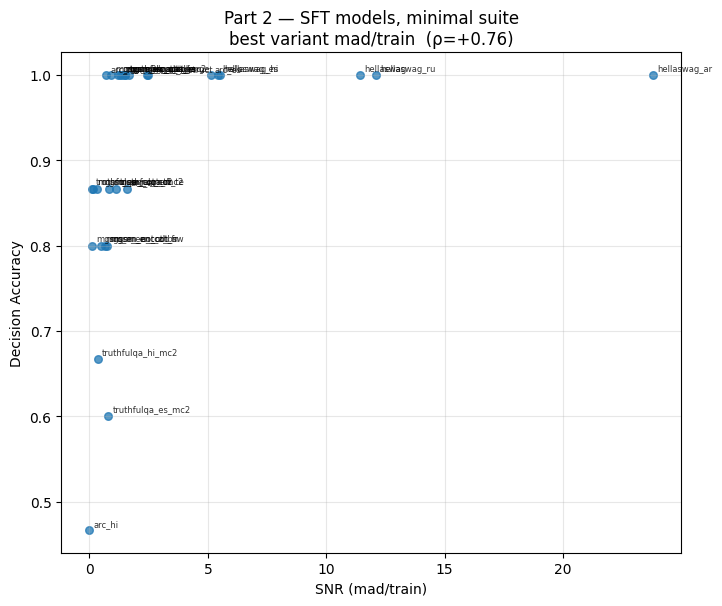

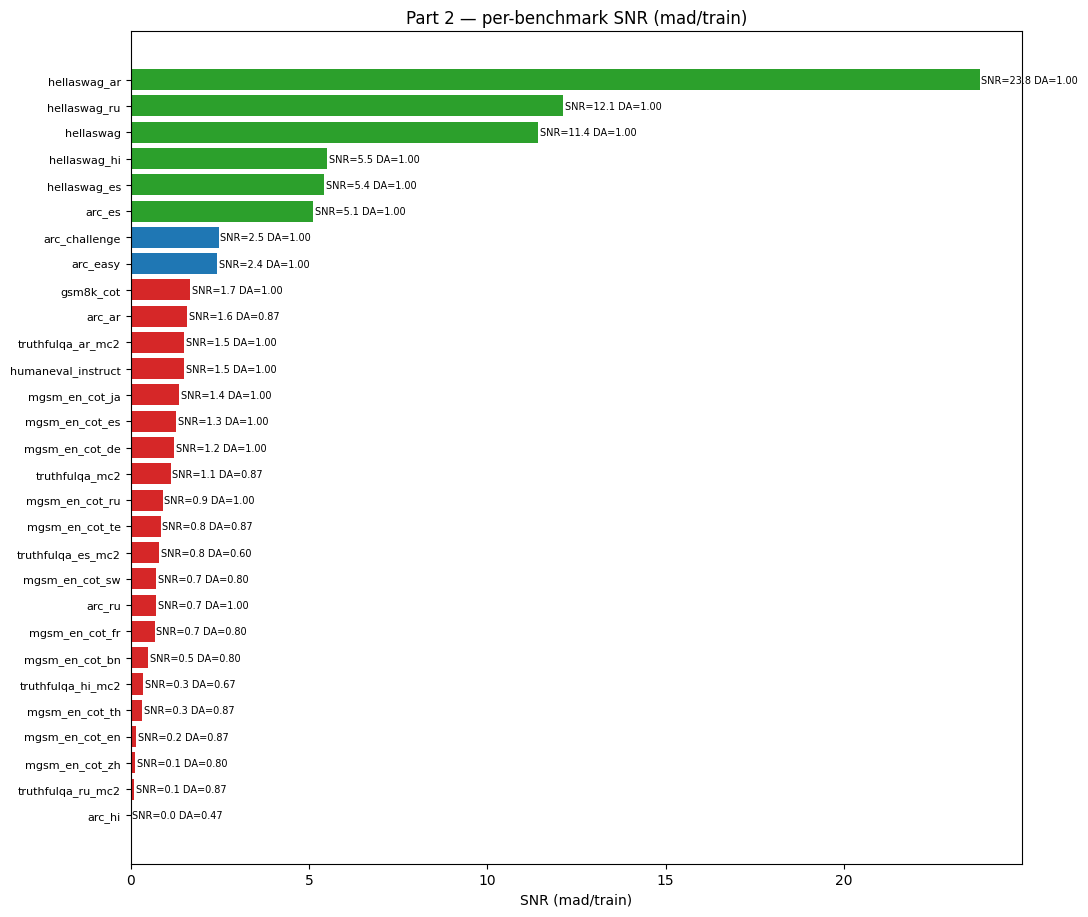

In [3]:
SFT = df[df["model_type"] == "sft"]
print("SFT models:", sorted(SFT["model"].unique()), "| ckpts/model:", SFT.groupby("model")["name"].nunique().to_dict())
S_sft = compute_records(SFT, minimal)
corrs_sft = variant_corrs(S_sft)
nda = [t for t in S_sft if S_sft[t]["da"] is not None]
print(f"{len(nda)} benchmarks with DA | mean DA = {np.mean([S_sft[t]['da'] for t in nda]):.3f}")
print("TOP 5 SNR variants:", [(n, round(v,3)) for n, v in corrs_sft[:5]])
plot_variant_bar(corrs_sft, f"Part 2 (SFT models) — SNR variant vs DA ({len(nda)} benchmarks)")
plot_best_scatter(S_sft, corrs_sft, "Part 2 — SFT models, minimal suite")
plot_perbench_snr(S_sft, corrs_sft[0][0], f"Part 2 — per-benchmark SNR ({corrs_sft[0][0]})")

# 9. SNR & DA of the full extended model set (no fwEdu)

The extended dataset now spans the 4 mid-training models, the 3 custom SFT models, and the reference
trajectories (`SmolLM3-3B-checkpoints`, `Olmo-3-1025-7B`, `Apertus-8B-2509`, `apertus3-1b/3b-nodes`,
`apertus-0.6b/1b-from8b`) plus single-checkpoint reference models — **excluding** the `fwEdu`
custom-pretrained runs. We run the same pipeline first on the `minimal` suite, then on the full
posttraining benchmark suite (DA is computed wherever ≥2 model-lines have checkpoint curves).

minimal: 29 benchmarks with DA, up to 71 model-lines, mean DA=0.842
TOP 5: [('mpd/eval', 0.863), ('iqr/eval', 0.853), ('quartile_dev/eval', 0.853), ('aad/eval', 0.852), ('mad/eval', 0.832)]


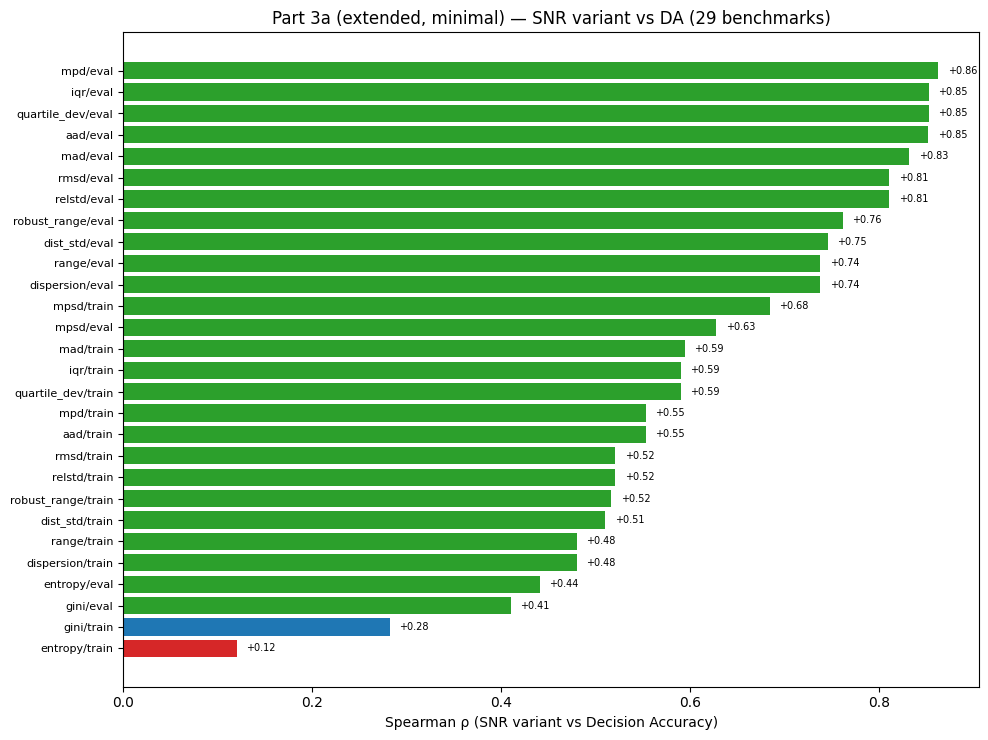

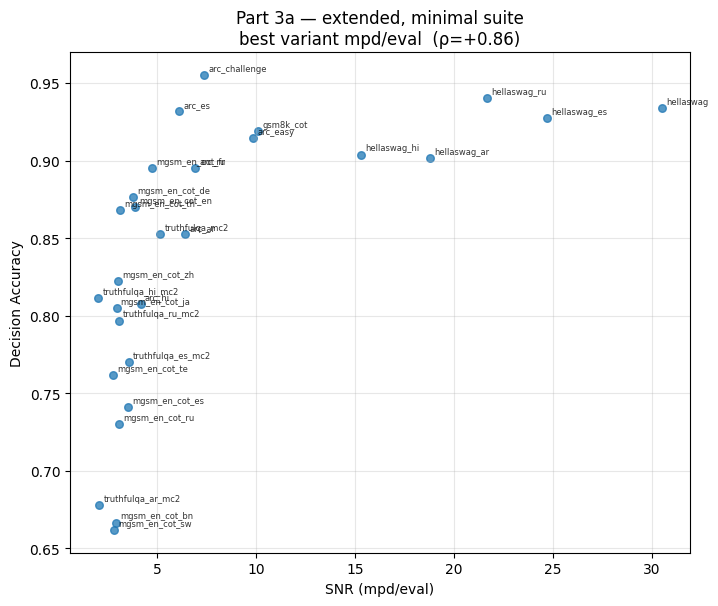

In [4]:
# Part 3a — minimal suite
S3m = compute_records(df, minimal)
corrs3m = variant_corrs(S3m)
nda=[t for t in S3m if S3m[t]["da"] is not None]
print(f"minimal: {len(nda)} benchmarks with DA, up to {max(r['n_lines'] for r in S3m.values())} model-lines, mean DA={np.mean([S3m[t]['da'] for t in nda]):.3f}")
print("TOP 5:", [(n, round(v,3)) for n,v in corrs3m[:5]])
plot_variant_bar(corrs3m, f"Part 3a (extended, minimal) — SNR variant vs DA ({len(nda)} benchmarks)")
plot_best_scatter(S3m, corrs3m, "Part 3a — extended, minimal suite")

full suite: 168/212 benchmarks have DA, mean DA=0.780
TOP 5: [('dist_std/eval', 0.619), ('aad/eval', 0.605), ('rmsd/eval', 0.602), ('relstd/eval', 0.602), ('mpd/eval', 0.599)]


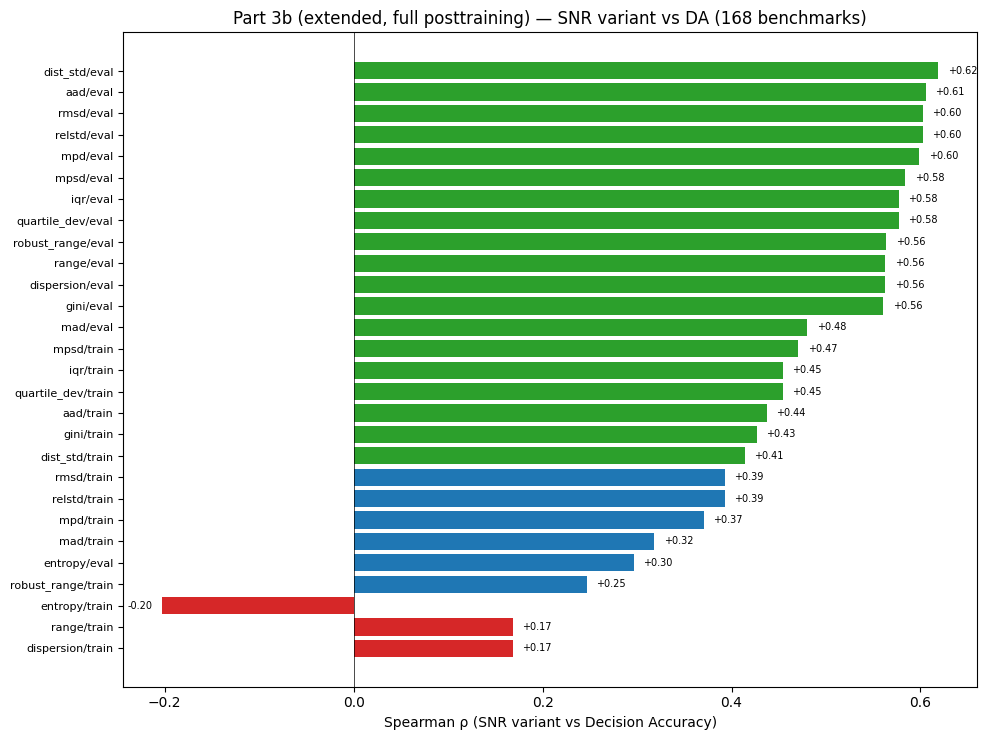

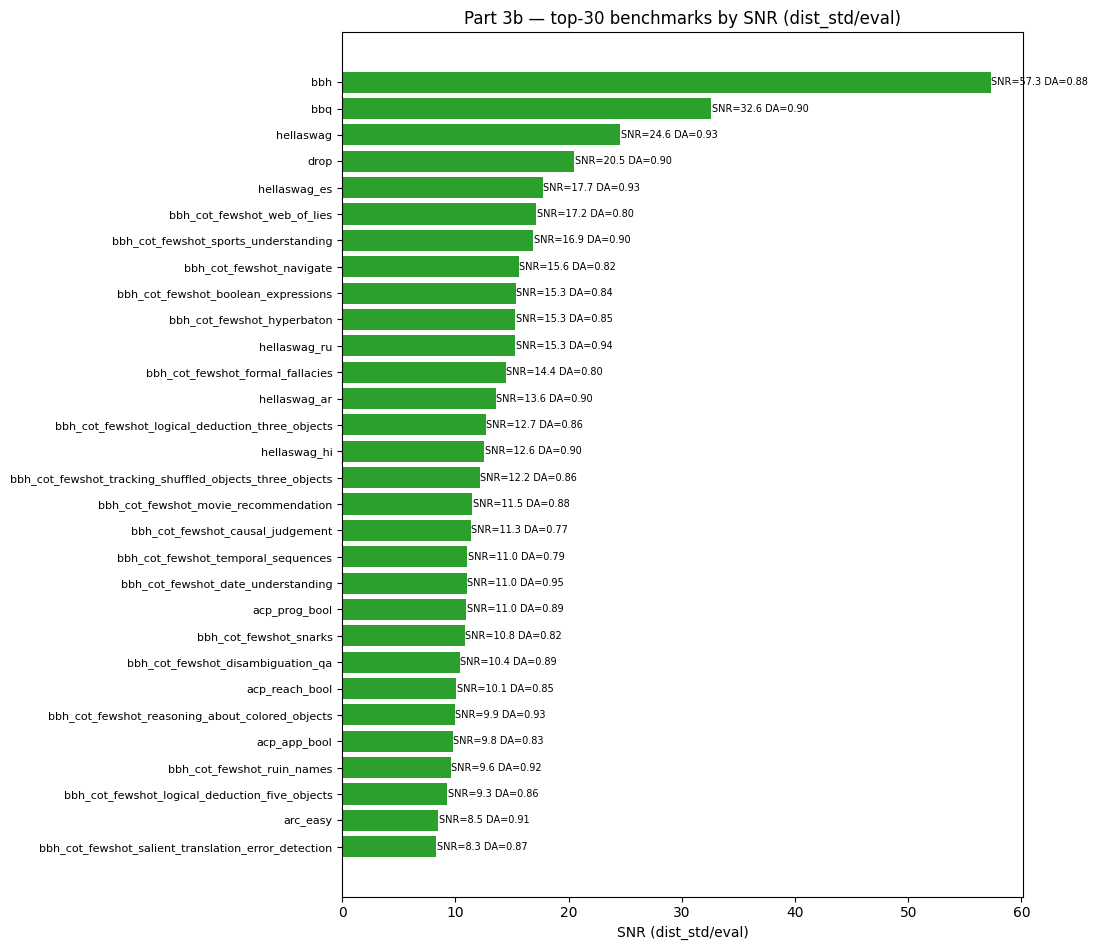

In [5]:
# Part 3b — full posttraining benchmark suite
S3p = compute_records(df, ALL_TASKS)
corrs3p = variant_corrs(S3p)
nda=[t for t in S3p if S3p[t]["da"] is not None]
print(f"full suite: {len(nda)}/{len(ALL_TASKS)} benchmarks have DA, mean DA={np.mean([S3p[t]['da'] for t in nda]):.3f}")
print("TOP 5:", [(n, round(v,3)) for n,v in corrs3p[:5]])
plot_variant_bar(corrs3p, f"Part 3b (extended, full posttraining) — SNR variant vs DA ({len(nda)} benchmarks)")
plot_perbench_snr(S3p, corrs3p[0][0], f"Part 3b — top-30 benchmarks by SNR ({corrs3p[0][0]})", topn=30)

**Sections 8–9 read-off.** Section 8 shows whether the SNR→DA relationship that Part 1 found on the 4
mid-training models also holds on a separate set of post-trained (SFT) models. Section 9 then scales the
same pipeline to the full extended model set and benchmark suite, surfacing which multilingual /
posttraining benchmarks separate models reliably (high SNR + high DA) versus which behave like noise.
The printed top-variant lists and the per-benchmark SNR bars are the concrete evidence.

# 10. Per-sample high-SNR subset selection (Option D)

Following `signal-and-noise/multilingual/smooth_subtasks_per_sample.py`, **Option D**
(`variance_prefilter` → drop "dead" samples whose per-group mean is constant across groups, then
**Option A**: order survivors by per-sample SNR and sweep the cumulative subset to its argmax). The
signal axis is the set of **model trajectories** (no `fwEdu` mixes available), and the per-sample
data comes **only** from `benchpress/posttraining-eval-results` (the 4 mid-training models) and
`benchpress/sft-eval-results` (the 3 SFT models). Left unexecuted here (downloads per-sample logs);
run the cells below to produce, per multilingual MC benchmark, the high-SNR sample subset and the
cumulative-SNR curve.

In [ ]:
import json, re, glob
from pathlib import Path
from collections import defaultdict
from huggingface_hub import snapshot_download

MC = ["arc_easy","arc_challenge","arc_es","arc_ar","arc_hi","arc_ru",
      "hellaswag","hellaswag_es","hellaswag_ar","hellaswag_hi","hellaswag_ru",
      "truthfulqa_mc2","truthfulqa_es_mc2","truthfulqa_ar_mc2","truthfulqa_hi_mc2","truthfulqa_ru_mc2"]
LAST_N = 5

# Download only the MC samples for both sample datasets (model = signal group, ckpts = noise).
roots = {}
for repo in ["benchpress/posttraining-eval-results", "benchpress/sft-eval-results"]:
    roots[repo] = snapshot_download(repo, repo_type="dataset",
                                    allow_patterns=[f"*/samples/{t}.jsonl" for t in MC])

def load_acc(path):
    out = {}
    for line in open(path):
        try: o = json.loads(line)
        except Exception: continue
        if "doc_id" in o and "acc" in o:
            try: out[int(o["doc_id"])] = float(o["acc"])
            except Exception: pass
    return out

# Build per-task {group(model): {ckpt_step: {doc_id: acc}}} pooling both datasets.
def gather(task):
    g = defaultdict(dict)
    for root in roots.values():
        for f in glob.glob(f"{root}/*/*/samples/{task}.jsonl"):
            parts = Path(f).parts
            model, ckpt = parts[-4], parts[-3]
            step = int(re.search(r"(\d+)", ckpt).group(1)) if re.search(r"(\d+)", ckpt) else 0
            accs = load_acc(f)
            if accs: g[model][(ckpt, step)] = accs
    return g

In [ ]:
def build_matrix(group):
    # rows = (model, ckpt) ordered; cols = doc_ids common to all rows; A[r,c]=acc
    rows = [(m, ck, st) for m, cks in group.items() for (ck, st) in cks]
    if len(rows) < 4: return None
    common = set.intersection(*[set(group[m][(ck, st)]) for (m, ck, st) in rows])
    if len(common) < 5: return None
    docs = sorted(common)
    A = np.array([[group[m][(ck, st)][d] for d in docs] for (m, ck, st) in rows], dtype=float)
    mix_rows = defaultdict(list)            # group = model; keep last-N ckpts by step
    for r, (m, ck, st) in enumerate(rows): mix_rows[m].append((st, r))
    mix_rows = {m: [r for _, r in sorted(v)[-LAST_N:]] for m, v in mix_rows.items()}
    mix_rows = {m: rs for m, rs in mix_rows.items() if len(rs) >= 2}   # drop sparse groups
    return (A, mix_rows, docs) if len(mix_rows) >= 2 else None

def signal_noise(combined, mix_rows):
    arrs = [combined[rs] for rs in mix_rows.values() if len(rs) >= 2]
    if len(arrs) < 2: return np.nan
    mm = np.array([a.mean() for a in arrs]); pooled = np.concatenate(arrs)
    if pooled.mean() == 0 or mm.mean() == 0: return np.nan
    sig = (mm.max()-mm.min())/mm.mean(); noise = pooled.std()/pooled.mean()
    return sig/noise if noise else np.nan

def per_sample_snr(A, mix_rows):
    mm = np.stack([A[rs].mean(0) for rs in mix_rows.values()], 0)
    pooled = A[[r for rs in mix_rows.values() for r in rs]]
    with np.errstate(divide="ignore", invalid="ignore"):
        snr = ((mm.max(0)-mm.min(0))/mm.mean(0)) / (pooled.std(0)/pooled.mean(0))
    return np.where(np.isfinite(snr), snr, np.nan)

def option_D(A, mix_rows):                  # variance_prefilter -> order by SNR
    mm = np.stack([A[rs].mean(0) for rs in mix_rows.values()], 0)
    alive = np.flatnonzero(mm.std(0) > 0)                # drop dead samples
    snr = per_sample_snr(A, mix_rows)
    fin = alive[np.isfinite(snr[alive])]
    return fin[np.argsort(-snr[fin])]

rows = []
for task in MC:
    built = build_matrix(gather(task))
    if built is None: continue
    A, mix_rows, docs = built
    order = option_D(A, mix_rows)
    if order.size == 0: continue
    cum = A[:, order].cumsum(1)
    curve = [signal_noise(cum[:, n-1]/n, mix_rows) for n in range(1, order.size+1)]
    best_n = int(np.nanargmax(curve)) + 1
    full = signal_noise(A.mean(1), mix_rows)
    rows.append(dict(task=task, n_total=A.shape[1], n_alive=order.size,
                     best_n=best_n, best_snr=curve[best_n-1], full_snr=full,
                     gain=curve[best_n-1]-full, curve=curve))
subset = pd.DataFrame([{k:v for k,v in r.items() if k!="curve"} for r in rows]).sort_values("gain", ascending=False)
print(subset.to_string(index=False))

In [ ]:
# Cumulative-SNR curves (sorted-by-SNR subset) for the benchmarks with the largest SNR gain
top = sorted(rows, key=lambda r: -r["gain"])[:6]
fig, axes = plt.subplots((len(top)+2)//3, 3, figsize=(15, 3.2*((len(top)+2)//3)), squeeze=False)
for ax, r in zip(axes.flat, top):
    ax.plot(range(1, len(r["curve"])+1), r["curve"], lw=1)
    ax.axvline(r["best_n"], color="grey", ls="--", lw=0.7)
    ax.axhline(r["full_snr"], color="r", ls=":", lw=0.7)
    ax.set_title(f"{r['task']} — best top-{r['best_n']}/{r['n_total']} "
                 f"(SNR {r['best_snr']:.2f} vs full {r['full_snr']:.2f})", fontsize=9)
    ax.set_xlabel("subset size (samples in SNR order)"); ax.set_ylabel("combined SNR"); ax.grid(alpha=0.2)
for ax in axes.flat[len(top):]: ax.axis("off")
fig.suptitle("Part 4 — per-sample high-SNR subsets (Option D), samples from posttraining + SFT", y=1.02)
fig.tight_layout(); plt.show()

# Discussion

This notebook runs one Signal / Noise / Decision-Accuracy pipeline at three widening scopes — the 4
mid-training models (Part 1, §1–7), the 3 custom SFT models we post-trained (§8), and the full
extended fleet excluding the `fwEdu` pretraining runs (§9) — on the `minimal` suite and then on the
full posttraining suite.

**1. SNR predicts Decision Accuracy in every setting.** The best variant correlates positively with
DA throughout: `range/train` ρ ≈ **+0.84** on the mid-training models (§3), `mad/train` ρ ≈ **+0.76**
on the SFT models (§8), `mpd/eval` ρ ≈ **+0.86** on the extended set / minimal (§9a), and
`dist_std/eval` ρ ≈ **+0.60** on the full posttraining suite (§9b). The framework's core claim — that
a benchmark's signal-to-noise ratio tracks how reliably it ranks models — holds across mid-training,
instruction-tuning, and a heterogeneous set of 219 checkpoints.

**2. Which *noise* term is best is population-dependent.** On the small, size-homogeneous sets (4
mid-training models; 3 SFT models) the **train-noise** family — signal divided by
checkpoint-to-checkpoint variability — wins, reproducing the Allen AI default. Once the model set
becomes large and heterogeneous (§9, up to 71 model-lines spanning 270M–70B and pretraining / mid /
SFT / instruct stages), the **eval-noise** (`stderr`) family takes over. `noise_train` is only
scale-matched to the signal when both are measured on the same homogeneous trajectories; across a
diverse fleet the analytic `stderr` is the more consistent normaliser. *Practical guidance:* use
checkpoint `noise_train` for single-run / homogeneous comparisons and the harness `stderr` when
ranking benchmarks over a diverse model fleet.

**3. Spread-based signals beat distributional ones, everywhere.** `range`, `dispersion`, `mpd`,
`mad`, `rmsd` consistently top the variant ranking; `gini` and `entropy` sit near zero. DA depends on
simple separation of model scores, not on the shape of their distribution.

**4. Post-trained models are separated most stably.** Mean DA is highest for the SFT models (§8,
**0.90**), then the extended-minimal set (§9a, **0.84**), then the full posttraining suite (§9b,
**0.78**). The minimal multilingual MC benchmarks rank instruction-tuned models very reliably; the
broad suite is noisier but still yields DA on **168 of 212** benchmarks once multi-checkpoint
reference trajectories are folded in.

**5. Reliability is benchmark- and language-specific.** ARC and HellaSwag (incl. their
`ar / es / hi / ru` variants) sit in the high-SNR / high-DA corner across every scope, while
low-resource MGSM-CoT targets and fine-grained `cultural_bench` / `global_mmlu` single-subject splits
behave like noise. The per-benchmark SNR bars (§5, §8, §9) are the actionable output — they say which
multilingual benchmarks deserve evaluation budget at each training stage.

**Takeaway.** SNR is a robust, stage-agnostic criterion for choosing reliable multilingual
benchmarks, provided the noise term is matched to the model population: checkpoint noise for a single
run, `stderr` for a diverse fleet.